In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
import random


pair = 'DOT_USDT'
timeframe = '8h'
exchange = 'binance'
data_path = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/{pair}-{timeframe}.json'  # Adjust the path to your dataset



/tmp/ipykernel_425374/3544491398.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['position'].fillna(0, inplace=True)
/tmp/ipykernel_425374/3544491398.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

Best Parameters: [25, 38, 80, 10, 59]


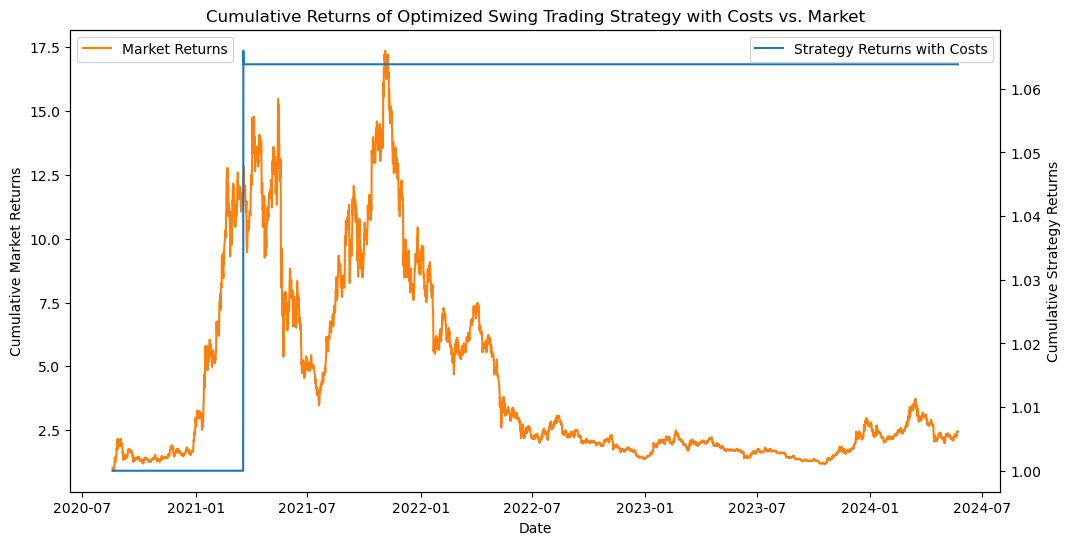

In [5]:

data = pd.read_json(data_path)

# Rename columns
data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']

# Convert timestamp to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')

# Set the timestamp as the index
data.set_index('timestamp', inplace=True)

# Function to calculate RSI
def calculate_rsi(df, period):
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Function to calculate moving averages
def calculate_moving_averages(df, short_period, long_period):
    df['short_ma'] = df['close'].rolling(window=short_period).mean()
    df['long_ma'] = df['close'].rolling(window=long_period).mean()
    return df

# Function to generate swing trading signals
def generate_swing_signals(df, rsi_period, rsi_lower, rsi_upper, short_ma_period, long_ma_period):
    df['rsi'] = calculate_rsi(df, rsi_period)
    df = calculate_moving_averages(df, short_ma_period, long_ma_period)
    df['signal'] = 0
    
    buy_condition = (df['rsi'] > rsi_lower) & (df['rsi'].shift(1) <= rsi_lower) & (df['short_ma'] > df['long_ma']) & (df['short_ma'].shift(1) <= df['long_ma'].shift(1))
    sell_condition = (df['rsi'] < rsi_upper) & (df['rsi'].shift(1) >= rsi_upper) & (df['short_ma'] < df['long_ma']) & (df['short_ma'].shift(1) >= df['long_ma'].shift(1))
    
    df.loc[buy_condition, 'signal'] = 1
    df.loc[sell_condition, 'signal'] = -1
    return df

# Function to backtest the strategy with fees and slippage
def backtest_strategy_with_costs(df, initial_capital=10000, trading_fee=0.001, slippage=0.001):
    df['position'] = df['signal'].shift()
    df['position'].fillna(0, inplace=True)
    df['returns'] = df['close'].pct_change()
    
    # Calculate strategy returns with trading fees and slippage
    df['strategy_returns'] = df['returns'] * df['position']
    df['strategy_returns_with_costs'] = df['strategy_returns'] - (trading_fee + slippage) * df['position'].diff().abs()
    
    df['cumulative_strategy_returns'] = (1 + df['strategy_returns_with_costs']).cumprod()
    df['cumulative_market_returns'] = (1 + df['returns']).cumprod()
    
    df['strategy_equity'] = initial_capital * df['cumulative_strategy_returns']
    df['market_equity'] = initial_capital * df['cumulative_market_returns']
    
    return df

# Initialize population
def initialize_population(pop_size, param_ranges):
    population = []
    for _ in range(pop_size):
        individual = [random.randint(param[0], param[1]) for param in param_ranges]
        population.append(individual)
    return population

# Evaluate fitness
def evaluate_fitness(individual, data):
    rsi_period, rsi_lower, rsi_upper, short_ma_period, long_ma_period = individual
    if rsi_lower >= rsi_upper or short_ma_period >= long_ma_period:
        return -np.inf
    
    data_copy = data.copy()
    data_copy = generate_swing_signals(data_copy, rsi_period, rsi_lower, rsi_upper, short_ma_period, long_ma_period)
    backtested_data = backtest_strategy_with_costs(data_copy)
    final_strategy_equity = backtested_data['strategy_equity'].iloc[-1]
    return final_strategy_equity

# Selection
def select_population(population, fitnesses, num_to_select):
    selected_indices = np.argsort(fitnesses)[-num_to_select:]
    return [population[i] for i in selected_indices]

# Crossover
def crossover(parent1, parent2):
    crossover_point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:crossover_point] + parent2[crossover_point:]
    child2 = parent2[:crossover_point] + parent1[crossover_point:]
    return child1, child2

# Mutation
def mutate(individual, param_ranges, mutation_rate=0.1):
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            individual[i] = random.randint(param_ranges[i][0], param_ranges[i][1])
    return individual

# Genetic algorithm parameters
pop_size = 50
num_generations = 40
num_to_select = 20
mutation_rate = 0.1
param_ranges = [(10, 30), (20, 40), (60, 80), (10, 30), (50, 100)]

# Run genetic algorithm
population = initialize_population(pop_size, param_ranges)
for generation in range(num_generations):
    fitnesses = [evaluate_fitness(individual, data) for individual in population]
    population = select_population(population, fitnesses, num_to_select)
    new_population = []
    while len(new_population) < pop_size:
        parent1, parent2 = random.sample(population, 2)
        child1, child2 = crossover(parent1, parent2)
        new_population.append(mutate(child1, param_ranges, mutation_rate))
        new_population.append(mutate(child2, param_ranges, mutation_rate))
    population = new_population

# Get the best individual
fitnesses = [evaluate_fitness(individual, data) for individual in population]
best_individual = population[np.argmax(fitnesses)]
best_parameters = best_individual

# Print the best parameters
print("Best Parameters:", best_parameters)

# Use the best parameters to generate and backtest the strategy
optimized_rsi_period, optimized_rsi_lower, optimized_rsi_upper, optimized_short_ma_period, optimized_long_ma_period = best_parameters

# Generate signals with optimized parameters
data_optimized_swing = generate_swing_signals(data.copy(), optimized_rsi_period, optimized_rsi_lower, optimized_rsi_upper, optimized_short_ma_period, optimized_long_ma_period)

# Backtest the strategy with optimized parameters including costs
backtested_data_optimized_swing = backtest_strategy_with_costs(data_optimized_swing)

# Plot the equity curves with cumulative strategy returns on a secondary y-axis with the correct timestamp
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot cumulative market returns on the primary y-axis
ax1.plot(backtested_data_optimized_swing.index, backtested_data_optimized_swing['cumulative_market_returns'], label='Market Returns', color='tab:orange')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Market Returns')
ax1.legend(loc='upper left')

# Create a secondary y-axis to plot the cumulative strategy returns
ax2 = ax1.twinx()
ax2.plot(backtested_data_optimized_swing.index, backtested_data_optimized_swing['cumulative_strategy_returns'], label='Strategy Returns with Costs', color='tab:blue')
ax2.set_ylabel('Cumulative Strategy Returns')
ax2.legend(loc='upper right')

plt.title('Cumulative Returns of Optimized Swing Trading Strategy with Costs vs. Market')
plt.show()
